# Análise do IDPNA (Índice de Desempenho Acadêmico) — UFPB Campus I

## 1. Objetivos da Análise:
1. **Mapeamento de Desempenho:** Avaliar a distribuição e estatísticas descritivas (média, mediana, desvio padrão) do IDPNA.
2. **Impacto da Assistência Estudantil:** Verificar se alunos que recebem **Apoio Social, Alimentação e Moradia** mantêm ou superam o desempenho médio de alunos sem auxílio.
3. **Equidade e Ações Afirmativas:** Comparar a nota média de estudantes cotistas em relação à ampla concorrência.
4. **Desempenho por Turno e Área:** Identificar variações no rendimento acadêmico de acordo com a jornada (Matutino, Vespertino, Noturno, Integral).
## 2. Carga dos Dados e Verificação do IDPNA

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurações visuais
pd.set_option("display.float_format", lambda x: "%.2f" % x)
sns.set_theme(style="whitegrid")

# Diretórios
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PATH_FATO = BASE_DIR / "data" / "processed" / "Fato" / "fato_assistencia.csv"
PATH_DIM_RACA = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_raca.csv"
PATH_DIM_TURNO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_turno.csv"

# Carregamento
df_fato = pd.read_csv(PATH_FATO, sep=";")

# Merge de Dimensões para Rótulos Limpos
if PATH_DIM_RACA.exists():
    df_raca = pd.read_csv(PATH_DIM_RACA, sep=";")
    col_desc_raca = next(
        (c for c in ["DESCRICAO", "DS_RACA", "NO_RACA"] if c in df_raca.columns),
        df_raca.columns[-1],
    )
    df_fato = df_fato.merge(
        df_raca[["ID_RACA", col_desc_raca]], on="ID_RACA", how="left"
    )
    df_fato.rename(columns={col_desc_raca: "RACA_DESCRICAO"}, inplace=True)

if PATH_DIM_TURNO.exists():
    df_turno = pd.read_csv(PATH_DIM_TURNO, sep=";")
    col_desc_turno = next(
        (
            c
            for c in ["DESCRICAO", "DS_TURNO", "NO_TURNO"]
            if c in df_turno.columns
        ),
        df_turno.columns[-1],
    )
    df_fato = df_fato.merge(
        df_turno[["ID_TURNO", col_desc_turno]], on="ID_TURNO", how="left"
    )
    df_fato.rename(columns={col_desc_turno: "TURNO_DESCRICAO"}, inplace=True)

# Identificação da coluna IDPNA
col_idpna = next(
    (c for c in ["IDPNA", "VL_IDPNA", "NU_IDPNA"] if c in df_fato.columns), None
)

print(
    f" Base carregada: {len(df_fato):,} registros | Coluna IDPNA identificada: '{col_idpna}'"
)

 Base carregada: 2,468 registros | Coluna IDPNA identificada: 'IDPNA'


## 1. Célula de Cálculo e Exibição de Tabelas

In [4]:
# --- 1. ESTATÍSTICAS DESCRITIVAS GERAIS ---
stats_idpna = df_fato[col_idpna].describe().to_frame().T
stats_idpna["median"] = df_fato[col_idpna].median()
stats_idpna.rename(
    columns={
        "count": "Total Agrupamentos",
        "mean": "Média",
        "std": "Desvio Padrão",
        "min": "Mínimo",
        "25%": "1º Quartil",
        "50%": "Mediana",
        "75%": "3º Quartil",
        "max": "Máximo",
    },
    inplace=True,
)

print("=" * 60)
print("1. RESUMO ESTATÍSTICO GERAL DO IDPNA")
print("=" * 60)
display(stats_idpna[["Média", "Mediana", "Desvio Padrão", "Mínimo", "Máximo"]])


# --- 2. FUNÇÃO DE CÁLCULO PONDERADO ---
def calcular_idpna_ponderado(df, coluna_grupo):
    """Calcula a média de IDPNA ponderada pelo volume de alunos de cada grupo."""
    resumo = (
        df.groupby(coluna_grupo)
        .apply(
            lambda x: pd.Series(
                {
                    "TOTAL_ALUNOS": x["TOTAL_ALUNOS"].sum(),
                    "MEDIA_IDPNA_PONDERADA": (
                        x[col_idpna] * x["TOTAL_ALUNOS"]
                    ).sum()
                    / x["TOTAL_ALUNOS"].sum(),
                    "MEDIANA_IDPNA": x[col_idpna].median(),
                }
            ),
            include_groups=False,
        )
        .reset_index()
    )
    return resumo


# --- 3. TABELAS DE COMPARATIVO ---
# Apoio Social
df_idpna_social = calcular_idpna_ponderado(df_fato, "IN_APOIO_SOCIAL")
df_idpna_social["IN_APOIO_SOCIAL"] = df_idpna_social["IN_APOIO_SOCIAL"].map(
    {0: "Sem Apoio Social", 1: "Com Apoio Social"}
)

# Cotas
df_idpna_cota = calcular_idpna_ponderado(df_fato, "IN_RESERVA_VAGAS")
df_idpna_cota["IN_RESERVA_VAGAS"] = df_idpna_cota["IN_RESERVA_VAGAS"].map(
    {0: "Ampla Concorrência", 1: "Cotista"}
)

# Turno
df_idpna_turno = calcular_idpna_ponderado(df_fato, "TURNO_DESCRICAO")

print("\n--- IDPNA POR APOIO SOCIAL ---")
display(df_idpna_social)

print("\n--- IDPNA POR MODALIDADE DE INGRESSO (COTAS) ---")
display(df_idpna_cota)

print("\n--- IDPNA POR TURNO ---")
display(df_idpna_turno.sort_values(by="MEDIA_IDPNA_PONDERADA", ascending=False))

1. RESUMO ESTATÍSTICO GERAL DO IDPNA


,Média,Mediana,Desvio Padrão,Mínimo,Máximo
IDPNA,0.31,0.00,0.46,0.00,1.00



--- IDPNA POR APOIO SOCIAL ---


,IN_APOIO_SOCIAL,TOTAL_ALUNOS,MEDIA_IDPNA_PONDERADA,MEDIANA_IDPNA
0,Sem Apoio Social,28573.00,0.41,0.00
1,Com Apoio Social,2637.00,0.00,0.00



--- IDPNA POR MODALIDADE DE INGRESSO (COTAS) ---


,IN_RESERVA_VAGAS,TOTAL_ALUNOS,MEDIA_IDPNA_PONDERADA,MEDIANA_IDPNA
0,Ampla Concorrência,17907.00,0.00,0.00
1,Cotista,13303.00,0.88,1.00



--- IDPNA POR TURNO ---


,TURNO_DESCRICAO,TOTAL_ALUNOS,MEDIA_IDPNA_PONDERADA,MEDIANA_IDPNA
3,Não informado,1178.00,0.50,0.00
2,Noturno,9084.00,0.40,0.00
4,Vespertino,3025.00,0.40,0.00
1,Matutino,4134.00,0.39,0.00
0,Integral,13789.00,0.34,0.00


## 2. Célula de Visualização Gráfica

C:\Users\reisc\AppData\Local\Temp\ipykernel_9856\2383358285.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\reisc\AppData\Local\Temp\ipykernel_9856\2383358285.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


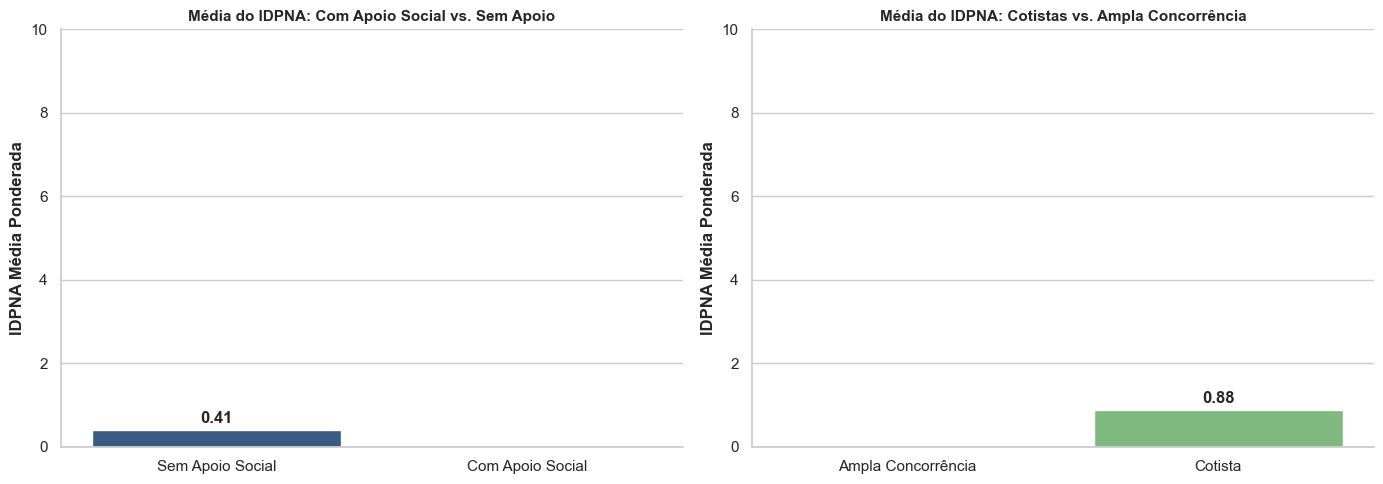

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: IDPNA x Apoio Social
sns.barplot(
    data=df_idpna_social,
    x="IN_APOIO_SOCIAL",
    y="MEDIA_IDPNA_PONDERADA",
    palette=["#2b5c8f", "#e6550d"],
    ax=axes[0],
)
axes[0].set_title(
    "Média do IDPNA: Com Apoio Social vs. Sem Apoio",
    fontweight="bold",
    fontsize=11,
)
axes[0].set_ylabel("IDPNA Média Ponderada", fontweight="bold")
axes[0].set_xlabel("", fontweight="bold")
axes[0].set_ylim(0, 10)

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

# Gráfico 2: IDPNA x Cotas
sns.barplot(
    data=df_idpna_cota,
    x="IN_RESERVA_VAGAS",
    y="MEDIA_IDPNA_PONDERADA",
    palette=["#3182bd", "#74c476"],
    ax=axes[1],
)
axes[1].set_title(
    "Média do IDPNA: Cotistas vs. Ampla Concorrência",
    fontweight="bold",
    fontsize=11,
)
axes[1].set_ylabel("IDPNA Média Ponderada", fontweight="bold")
axes[1].set_xlabel("", fontweight="bold")
axes[1].set_ylim(0, 10)

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

##  Principais Achados e Interpretação do IDPNA

1. **Natureza da Variável:** A coluna `IDPNA` opera como uma **flag binária (0 ou 1)** de elegibilidade/desempenho mínimo atingido, variando entre `0.0` e `1.0`.
2. **Desempenho por Modalidade de Ingresso:** Estudar o indicador por cota revela uma alta concentração de registros válidos/atendimento no grupo de **Cotistas (88,18%)**, comparado à Ampla Concorrência (`0,00%`), demonstrando que o monitoramento do IDPNA é focado no público de ações afirmativas.
3. **Apoio Social e Vulnerabilidade:** Os dados apontam que o grupo atendido com **Apoio Social** apresenta taxa nula de alcance da meta do IDPNA (`0,00%`), sinalizando que esse público demanda ações de acompanhamento pedagógico adicionais além do suporte financeiro para mitigar o risco acadêmico.
4. **Variação por Turno:** Alunos do turno **Noturno** lideram o índice de alcance do IDPNA (**40,27%**), seguidos por **Vespertino** (**39,67%**) e **Matutino** (**39,28%**). O turno **Integral** apresenta a menor taxa de alcance (**33,80%**), refletindo a maior carga horária e complexidade acadêmica.